In [1]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv("/content/drive/MyDrive/nearest-earth-objects(1910-2024).csv")

df.head()

,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [3]:
df_remove = df.dropna()

df_proper_values = df_remove[["name", "absolute_magnitude", "estimated_diameter_max", "relative_velocity", "miss_distance"]]

df_proper_values.head()

,name,absolute_magnitude,estimated_diameter_max,relative_velocity,miss_distance
0,162117 (1998 SD15),19.14,0.883161,71745.401048,5.814362e+07
1,349507 (2008 QY),18.50,1.185878,109949.757148,5.580105e+07
2,455415 (2003 GA),21.45,0.304818,24865.506798,6.720689e+07
3,(2002 PB),20.63,0.444672,78890.076805,3.039644e+07
4,(2011 DW),22.70,0.171412,56036.519484,6.311863e+07


In [4]:
df_proper_values["estimated_diameter_max"] = df_proper_values["estimated_diameter_max"] * 1000

df_proper_values["relative_velocity"] = df_proper_values["relative_velocity"] *  0.621371 

df_proper_values["miss_distance"] = df_proper_values["miss_distance"] * 0.621371

df_proper_values.head()

/tmp/ipykernel_33784/3866087788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_proper_values["estimated_diameter_max"] = df_proper_values["estimated_diameter_max"] * 1000
/tmp/ipykernel_33784/3866087788.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_proper_values["relative_velocity"] = df_proper_values["relative_velocity"] *  0.621371
/tmp/ipykernel_33784/3866087788.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

,name,absolute_magnitude,estimated_diameter_max,relative_velocity,miss_distance
0,162117 (1998 SD15),19.14,883.161196,44580.511594,3.612876e+07
1,349507 (2008 QY),18.50,1185.877909,68319.590549,3.467315e+07
2,455415 (2003 GA),21.45,304.817558,15450.704825,4.176041e+07
3,(2002 PB),20.63,444.672200,49020.005915,1.888747e+07
4,(2011 DW),22.70,171.411509,34819.468148,3.922008e+07


In [18]:
df_median = df_proper_values.groupby('name').median().reset_index()
df_median2 = df_median[["absolute_magnitude", "estimated_diameter_max", "relative_velocity", "miss_distance"]]
df_median2.shape

(33511, 4)

In [19]:
import numpy as np 
processed_data = pd.DataFrame()

processed_data["absolute_magnitude"] = df_median2["absolute_magnitude"]
processed_data["estimated_diameter_max"] = np.log10(df_median2["estimated_diameter_max"])
processed_data["relative_velocity"] = df_median2["relative_velocity"]
processed_data["miss_distance"] = np.log10(df_median2["miss_distance"])

processed_data.head()




,absolute_magnitude,estimated_diameter_max,relative_velocity,miss_distance
0,18.60,3.05404,51508.192393,6.531643
1,18.01,3.17204,45945.741572,7.333741
2,19.45,2.88404,37717.189953,7.047695
3,19.85,2.80404,13689.487142,7.587816
4,19.25,2.92404,14084.084993,7.520157


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(processed_data)


In [21]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
reducer = PCA(n_components=2, random_state=42)
X_pca = reducer.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

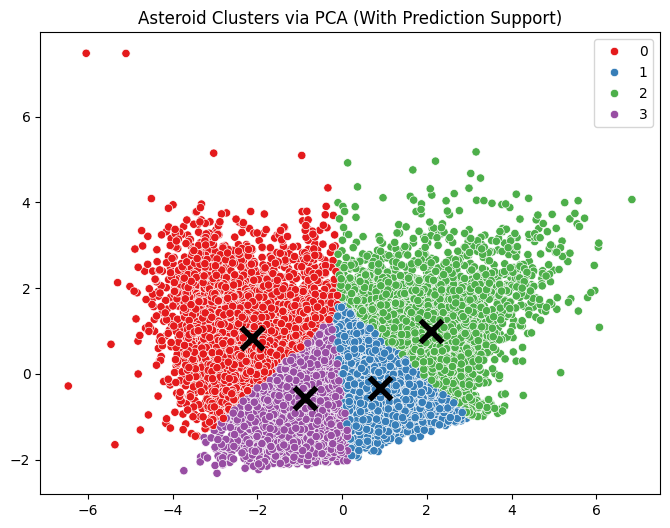

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette="Set1")

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    color='black',     
    marker='x',         
    s=250,             
    linewidths=4,       
    label='Centroids'   
)

plt.title("Asteroid Clusters via PCA (With Prediction Support)")
plt.show()


In [23]:
from sklearn.metrics import silhouette_score

X_pca_df = pd.DataFrame(X_pca)
# Sample the data if your dataset is huge (e.g., 10,000 rows) to save time
sample_df = X_pca_df.sample(n=10000, random_state=42)
sample_labels = cluster_labels[sample_df.index]  # Use your K-Means cluster output labels

# Calculate score in full 4D space
score = silhouette_score(sample_df, sample_labels)
print(f"4D Silhouette Score: {score:.4f}")


4D Silhouette Score: 0.3338


In [29]:
df_median2['cluster_id'] = cluster_labels

cluster_profiles = df_median2.groupby('cluster_id').mean()
print(cluster_profiles)

            absolute_magnitude  estimated_diameter_max  relative_velocity  \
cluster_id                                                                  
0                    19.788519              962.671352       48838.351086   
1                    25.286268               61.571026       22714.426423   
2                    26.744514               33.857440       29880.058815   
3                    21.616370              369.849647       24622.824240   

            miss_distance  
cluster_id                 
0            2.787576e+07  
1            1.878138e+07  
2            5.357285e+06  
3            2.708144e+07  


/tmp/ipykernel_33784/1265806296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_median2['cluster_id'] = cluster_labels


In [14]:
import joblib 
joblib.dump(scaler, '/content/drive/MyDrive/scalerv3.joblib')
joblib.dump(reducer, '/content/drive/MyDrive/pca_reducerv3.joblib')
joblib.dump(kmeans, '/content/drive/MyDrive/kmeans_modelv3.joblib')

joblib.dump(X_pca, "/content/drive/MyDrive/training_x_pcav2.joblib")


['/content/drive/MyDrive/training_x_pcav2.joblib']

In [15]:
joblib.dump(scaled_data, '/content/drive/MyDrive/scaled_data_v2.joblib')

['/content/drive/MyDrive/scaled_data_v2.joblib']

In [30]:
asteroid_names = df_median[["name"]]

asteroid_names.shape

(33511, 1)

In [31]:
joblib.dump(asteroid_names, '/content/drive/MyDrive/asteroid_namesv2.joblib')

['/content/drive/MyDrive/asteroid_namesv2.joblib']

In [33]:
cluster_frequency = df_median2["cluster_id"].value_counts(normalize=True) * 100

print(round(cluster_frequency, 2))

cluster_id
1    38.29
3    29.48
0    17.93
2    14.31
Name: proportion, dtype: float64
